Initialization

In [233]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from statsmodels.stats.anova import anova_lm
from statsmodels.formula.api import ols
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

In [234]:
df = pd.read_csv('C:/Users/josep/OneDrive/Desktop/small python project/Flatmate Compatibility/training_data.csv')
df

,student1_id,student1_name,student1_budget_min,student1_budget_max,student1_university,student1_course,student1_yearOfStudy,student1_age,student1_nationality,student1_propertyType,...,student2_yearOfStudy,student2_age,student2_nationality,student2_propertyType,student2_smoking,student2_petFriendly,student2_cleanliness,student2_noiseTolerance,student2_bio,compatibility_score
0,1,Sarah Chen,600,900,NTU,Computer Science,2,20,Singaporean,"HDB,Condo",...,3,21,Singaporean,"HDB,Condo",No,No,Very Clean,Low,Final year engineering student with a focus on...,92
1,3,Marcus Rivera,800,1200,NUS,Business Administration,1,19,American,"Condo,Landed",...,2,20,Australian,"Condo,Landed",Yes,Yes,Moderate,High,Second year business student active in entrepr...,88
2,5,Priya Sharma,500,700,NTU,Biomedical Engineering,3,22,Indian,HDB,...,3,23,Indian,HDB,No,No,Very Clean,Low,Pharmaceutical sciences researcher working on ...,95
3,7,David Wong,1000,1500,NUS,Law,2,21,Singaporean,"Condo,Landed",...,2,20,Singaporean,HDB,No,No,Clean,Moderate,Accounting student preparing for professional ...,68
4,9,Alex Johnson,700,1000,SMU,Communications,1,19,British,"HDB,Condo",...,2,20,Canadian,"HDB,Condo",Yes,Yes,Moderate,High,Film studies student working on documentary pr...,90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1328,2013,Pooja White,500,800,SUSS,Public Policy,4,22,Jordanian,Condo,...,2,19,French,"HDB,Condo,Landed",No,No,Moderate,Low,Robotics PhD working on soft-bodied robots ins...,55
1329,2015,Ye Jin Lin,900,1300,SMU,Culinary Arts,4,21,Indian,Landed,...,1,19,Spanish,Condo,No,No,Very Clean,Moderate,Grew up in a houseboat in Kerala. Water was al...,31
1330,2017,Natsuki Chukwu,750,950,SP Jain,Nursing,2,19,Swedish,"HDB,Condo",...,1,19,Nepali,"Condo,Landed",No,No,Clean,Low,Former professional swimmer studying sports ps...,84
1331,2019,James Colombo,1200,1550,Murdoch Singapore,Chemical Engineering,3,20,Cambodian,Landed,...,2,21,Uzbek,"Condo,Landed",No,Yes,Moderate,Low,I teach calligraphy on Saturday mornings. Ink ...,78


Initial EDA

In [235]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1333 entries, 0 to 1332
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   student1_id              1333 non-null   int64 
 1   student1_name            1333 non-null   object
 2   student1_budget_min      1333 non-null   int64 
 3   student1_budget_max      1333 non-null   int64 
 4   student1_university      1333 non-null   object
 5   student1_course          1333 non-null   object
 6   student1_yearOfStudy     1333 non-null   int64 
 7   student1_age             1333 non-null   int64 
 8   student1_nationality     1333 non-null   object
 9   student1_propertyType    1333 non-null   object
 10  student1_smoking         1333 non-null   object
 11  student1_petFriendly     1333 non-null   object
 12  student1_cleanliness     1333 non-null   object
 13  student1_noiseTolerance  1333 non-null   object
 14  student1_bio             1333 non-null  

In [236]:
df.isnull().sum()

student1_id                0
student1_name              0
student1_budget_min        0
student1_budget_max        0
student1_university        0
student1_course            0
student1_yearOfStudy       0
student1_age               0
student1_nationality       0
student1_propertyType      0
student1_smoking           0
student1_petFriendly       0
student1_cleanliness       0
student1_noiseTolerance    0
student1_bio               0
student2_id                0
student2_name              0
student2_budget_min        0
student2_budget_max        0
student2_university        0
student2_course            0
student2_yearOfStudy       0
student2_age               0
student2_nationality       0
student2_propertyType      0
student2_smoking           0
student2_petFriendly       0
student2_cleanliness       0
student2_noiseTolerance    0
student2_bio               0
compatibility_score        0
dtype: int64

In [237]:
df[df.duplicated()]

,student1_id,student1_name,student1_budget_min,student1_budget_max,student1_university,student1_course,student1_yearOfStudy,student1_age,student1_nationality,student1_propertyType,...,student2_yearOfStudy,student2_age,student2_nationality,student2_propertyType,student2_smoking,student2_petFriendly,student2_cleanliness,student2_noiseTolerance,student2_bio,compatibility_score


In [238]:
df.describe()

,student1_id,student1_budget_min,student1_budget_max,student1_yearOfStudy,student1_age,student2_id,student2_budget_min,student2_budget_max,student2_yearOfStudy,student2_age,compatibility_score
count,1333.000000,1333.000000,1333.000000,1333.000000,1333.000000,1333.000000,1333.000000,1333.000000,1333.000000,1333.000000,1333.000000
mean,819.567892,738.072018,1060.165041,2.421605,20.500375,820.567892,750.917479,1074.173293,2.527382,20.600900,69.198050
std,614.020492,226.285691,259.857844,1.092926,1.400678,614.020492,246.698265,274.350107,1.085756,1.376464,17.721691
min,1.000000,400.000000,550.000000,1.000000,18.000000,2.000000,216.000000,502.000000,1.000000,18.000000,10.000000
25%,251.000000,550.000000,850.000000,1.000000,19.000000,252.000000,550.000000,864.000000,2.000000,20.000000,56.000000
50%,689.000000,700.000000,1050.000000,2.000000,20.000000,690.000000,710.000000,1050.000000,3.000000,21.000000,71.000000
75%,1355.000000,900.000000,1250.000000,3.000000,21.000000,1356.000000,900.000000,1250.000000,3.000000,22.000000,84.000000
max,2021.000000,1400.000000,2000.000000,4.000000,24.000000,2022.000000,1736.000000,2218.000000,4.000000,25.000000,99.000000


Feature Exploratory

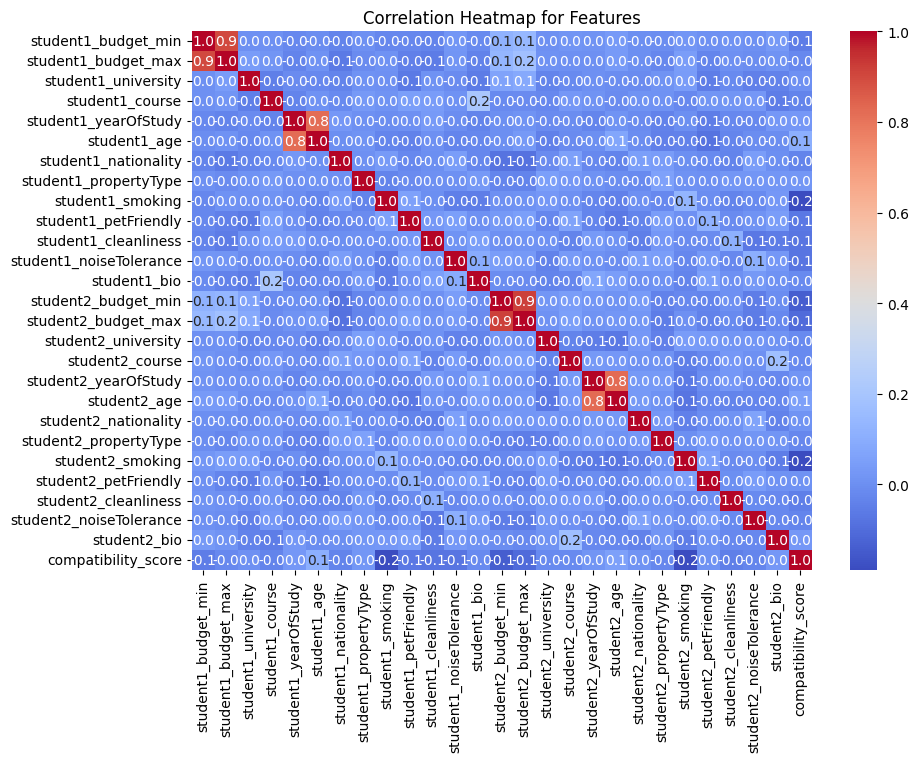

In [239]:
df_encoded = df.copy()
df_encoded = df_encoded.drop(columns=['student1_id','student1_name','student2_id','student2_name'])

numerical_cols = df_encoded.select_dtypes(include='number').columns
categorical_cols = df_encoded.select_dtypes(include='object').columns

le = LabelEncoder()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])
corr_df = df_encoded.corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr_df, annot=True, fmt='.1f', cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap for Features')
plt.show()

#age and years of study show 0.8 correlation but they are both different interpretation

#similar to minimum and maximum budget, although further feature study is needed 
#to determine if dropping either affects the model in a signifcant meaning


In [240]:
#cleaning lifestyle features to numerical features for anova
df['student1_smoking'] = df['student1_smoking'].apply(lambda x: 1 if 'Yes' else 2)
df['student2_smoking'] = df['student2_smoking'].apply(lambda x: 1 if 'Yes' else 2)

df['student1_petFriendly'] = df['student1_petFriendly'].apply(lambda x: 1 if 'Yes' else 2)
df['student2_petFriendly'] = df['student2_petFriendly'].apply(lambda x: 1 if 'Yes' else 2)

df['student1_cleanliness'] = df['student1_cleanliness'].map(
    {'Very Clean':1, 'Clean':2, 'Moderate':3, 'Relaxed':4}).fillna(5)
df['student2_cleanliness'] = df['student2_cleanliness'].map(
    {'Very Clean':1, 'Clean':2, 'Moderate':3, 'Relaxed':4}).fillna(5)

df['student1_noiseTolerance'] = df['student1_noiseTolerance'].map(
    {'Very High':1, 'High':2, 'Moderate':3, 'Low':4, 'Very Low':5}).fillna(6).astype(int)
df['student2_noiseTolerance'] = df['student2_noiseTolerance'].map(
    {'Very High':1, 'High':2, 'Moderate':3, 'Low':4, 'Very Low':5}).fillna(6).astype(int)

In [241]:
numerical_cols = df.select_dtypes(include='number').columns
features = df[numerical_cols]
features = features.drop(columns=['student1_id','student2_id','compatibility_score'])

formula = 'compatibility_score ~ ' + ' + '.join(features)
model = ols(formula, data=df).fit() 
anova_res = anova_lm(model)
anova_res

,df,sum_sq,mean_sq,F,PR(>F)
student1_budget_min,1.0,1112.827857,1112.827857,3.781194,5.204385e-02
student1_budget_max,1.0,1356.950311,1356.950311,4.610679,3.195513e-02
student1_yearOfStudy,1.0,320.397065,320.397065,1.088653,2.969609e-01
student1_age,1.0,8375.473295,8375.473295,28.458387,1.125401e-07
student1_smoking,1.0,516.086745,516.086745,1.753572,1.856575e-01
student1_petFriendly,1.0,440.740355,440.740355,1.497558,2.212658e-01
student1_cleanliness,1.0,1537.707817,1537.707817,5.224861,2.242412e-02
student1_noiseTolerance,1.0,236.504014,236.504014,0.803599,3.701829e-01
student2_budget_min,1.0,8150.639152,8150.639152,27.694440,1.656405e-07
student2_budget_max,1.0,1043.695129,1043.695129,3.546293,5.989836e-02


In [242]:
df['age_diff'] = abs(df['student1_age'] - df['student2_age'])
df['budget_min_diff'] = abs(df['student1_budget_min'] - df['student2_budget_min'])
df['budget_max_diff'] = abs(df['student1_budget_max'] - df['student2_budget_max'])
df['cleanliness_diff'] = abs(df['student1_cleanliness'] - df['student2_cleanliness']).astype(int)
df['noise_diff'] = abs(df['student1_noiseTolerance'] - df['student2_noiseTolerance']).astype(int)
df['study_diff'] = abs(df['student1_yearOfStudy'] - df['student2_yearOfStudy']).astype(int)

df['smoking_match'] = (df['student1_smoking'] == df['student2_smoking']).astype(int)
df['pet_match'] = (df['student1_petFriendly'] == df['student2_petFriendly']).astype(int)
df['university_match'] = (df['student1_university'] == df['student2_university']).astype(int)
df['course_match'] = (df['student1_course'] == df['student2_course']).astype(int)
df['nationality_match'] = (df['student1_nationality'] == df['student2_nationality']).astype(int)

formula = '''compatibility_score ~ age_diff + budget_min_diff + budget_max_diff + smoking_match + 
            pet_match + cleanliness_diff + noise_diff + university_match + course_match +
            nationality_match + study_diff'''

model = ols(formula, data=df).fit() 
anova_res = anova_lm(model)
anova_res

,df,sum_sq,mean_sq,F,PR(>F)
age_diff,1.0,6073.321322,6073.321322,34.279514,6.013866e-09
budget_min_diff,1.0,97737.620959,97737.620959,551.658303,3.018396e-102
budget_max_diff,1.0,5638.264434,5638.264434,31.823932,2.061925e-08
smoking_match,1.0,172.129410,172.129410,0.971546,3.244751e-01
pet_match,1.0,128.320644,128.320644,0.724277,3.948984e-01
cleanliness_diff,1.0,39262.711895,39262.711895,221.609661,1.857778e-46
noise_diff,1.0,28942.131978,28942.131978,163.357439,2.345605e-35
university_match,1.0,1926.796475,1926.796475,10.875375,1.000398e-03
course_match,1.0,66.654811,66.654811,0.376218,5.397396e-01
nationality_match,1.0,46.001060,46.001060,0.259643,6.104507e-01


In [243]:
df_ml = df.copy()
X = (df_ml[['age_diff','budget_min_diff','budget_max_diff','cleanliness_diff','noise_diff','university_match',
            'study_diff']])
y = df_ml['compatibility_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [244]:
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print(scores)
print("Mean R²:", scores.mean())

[0.42905365 0.46671056 0.32893228 0.4001047  0.33906775]
Mean R²: 0.39277378978303873
